# 8.4 Monitoring-Network Design

**Part:** 8 — Spatial Sampling and Design (Chapter 8.4 of 5)

**Dataset:** `CA_pm25_2025.csv` (Part 7's 159-site California PM2.5 monitor network)

**Focus:** where the current network has gaps; `coverage_metrics` for design comparison; sequential placement by kriging variance

**Library:** `spatialstats.sampling`, `spatialstats.interpolate` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [How Good Is the Current Network, Really?](#3.-How-Good-Is-the-Current-Network,-Really?)
4.. [Space-Filling as an Alternative](#4.-Space-Filling-as-an-Alternative)
5.. [Sequential Selection by Kriging Variance](#5.-Sequential-Selection-by-Kriging-Variance)
6.. [Sequential Selection by Maximin Distance](#6.-Sequential-Selection-by-Maximin-Distance)
7.. [Where Would New Monitors Actually Go?](#7.-Where-Would-New-Monitors-Actually-Go?)
8.. [Summary and Conclusions](#8.-Summary-and-Conclusions)
9.. [Resources](#9.-Resources)

***
## 1. Overview

Part 7 built kriging models and cross-validated interpolators on California's 159-monitor PM2.5 network without
ever asking whether that network is any good as a *design*. This chapter asks exactly that — quantifying the
current network's coverage, comparing it against what a purpose-built design would achieve at the same size, and
then addressing the more practical question: **given the network as it exists today, where should the next few
monitors go?**

| Step | What we do |
|------|------------|
| Audit | `coverage_metrics` on the real 159-site network: mean/max distance to nearest monitor, minimum spacing, balance |
| Compare | The same metrics for a random and a `space_filling` network of the same size |
| Sequential placement | Add monitors one at a time, each one where the current kriging model is least certain |
| An alternative | The same idea using pure geometry (maximin distance) instead of a fitted variogram |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.sampling import SpatialSample, space_filling, coverage_metrics
from spatialstats.interpolate import OrdinaryKriging, make_grid

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

pm25_raw = pd.read_csv(DATA / "CA_pm25_2025.csv")
site_means = (
    pm25_raw.groupby("Site ID")
    .agg(Lat=("Lat", "first"), Long=("Long", "first"),
         pm25=("Daily_PM2.5_ug_m3", "mean"), n_obs=("Daily_PM2.5_ug_m3", "size"))
    .reset_index()
)
site_means = site_means[site_means["n_obs"] >= 100].reset_index(drop=True)
site_gdf = gpd.GeoDataFrame(
    site_means, geometry=gpd.points_from_xy(site_means["Long"], site_means["Lat"]), crs="EPSG:4326"
).to_crs("EPSG:3310")
monitor_coords = np.c_[site_gdf.geometry.x, site_gdf.geometry.y]
monitor_values = site_gdf["pm25"].to_numpy()
print(f"spatialstats : version {spatialstats.__version__}")
print(f"current network: {len(monitor_coords)} monitors")

spatialstats : version 0.2.0
current network: 159 monitors


***
## 3. How Good Is the Current Network, Really?

`coverage_metrics` needs a reference "frame" — a candidate universe of locations the network should be evaluated
against — separate from the monitors themselves. A fine grid over the monitor network's own bounding extent
serves that purpose here: it lets us ask "if PM2.5 could be measured anywhere in this region, how far is the
nearest monitor, on average and at worst?"

In [2]:
reference_grid = make_grid(monitor_coords, n_cells=60).coords
combined = np.vstack([reference_grid, monitor_coords])
n_ref = len(reference_grid)
current_idx = np.arange(n_ref, n_ref + len(monitor_coords))

current_sample = SpatialSample("current", current_idx, np.ones(len(monitor_coords)), combined)
current_metrics = coverage_metrics(current_sample)
for k, v in current_metrics.items():
    unit = " m" if "dist" in k or "spacing" in k else ""
    print(f"{k:22s}: {v:,.1f}{unit}")

balance               : 3.2
mean_dist_to_sample   : 103,848.9 m
max_dist_to_sample    : 496,776.3 m
min_spacing           : 1,110.5 m


The **minimum spacing** of about a kilometre confirms what Part 7 already suspected from the leave-one-out
optimism finding (Chapter 7.5): several monitors sit almost on top of each other. The **maximum distance to
nearest monitor**, in contrast, runs into the hundreds of kilometres — somewhere in this region, the nearest
working monitor is nearly the width of the state away.

***
## 4. Space-Filling as an Alternative

What would the *same number* of monitors look like if placed for coverage rather than accumulated
opportunistically over years of independent siting decisions?

In [3]:
rng = np.random.default_rng(1)
random_idx = rng.choice(n_ref, size=len(monitor_coords), replace=False)
random_sample = SpatialSample("random", random_idx, np.ones(len(monitor_coords)), combined)

cand_frame = pd.DataFrame({"X": reference_grid[:, 0], "Y": reference_grid[:, 1]})
sf = space_filling(cand_frame, n=len(monitor_coords), method="kmeans", seed=1)
sf_sample = SpatialSample("space_filling", sf.indices, np.ones(len(sf.indices)), combined)

comparison = pd.DataFrame({
    "current (real) network": current_metrics,
    "random, same n": coverage_metrics(random_sample),
    "space-filling, same n": coverage_metrics(sf_sample),
}).T
comparison.round(1)

,balance,mean_dist_to_sample,max_dist_to_sample,min_spacing
current (real) network,3.2,103848.9,496776.3,1110.5
"random, same n",0.3,36216.6,109426.5,17089.6
"space-filling, same n",0.0,27421.9,59255.9,48336.6


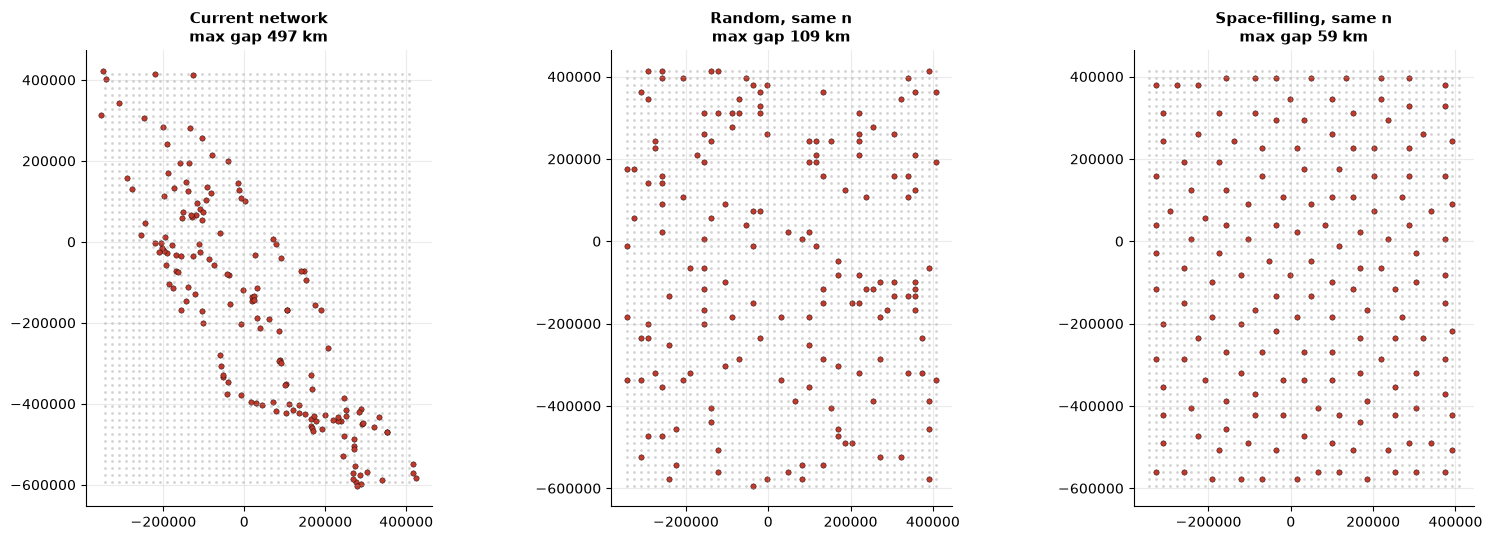

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, s, title in zip(axes, [current_sample, random_sample, sf_sample],
                        [f"Current network\nmax gap {current_metrics['max_dist_to_sample']/1000:.0f} km",
                         f"Random, same n\nmax gap {coverage_metrics(random_sample)['max_dist_to_sample']/1000:.0f} km",
                         f"Space-filling, same n\nmax gap {coverage_metrics(sf_sample)['max_dist_to_sample']/1000:.0f} km"]):
    ax.scatter(reference_grid[:, 0], reference_grid[:, 1], s=1, color="lightgrey")
    ax.scatter(s.coords[:, 0], s.coords[:, 1], s=15, color=COLORS["red"], edgecolor="k", linewidth=0.3)
    ax.set_title(title)
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("network_coverage_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

**The gap is dramatic.** At the same site count, a space-filling design cuts the mean distance to the nearest
monitor by more than half and the worst-case gap by a similar margin, while its minimum spacing is far larger —
no near-duplicate stations at all. This is not a criticism of how the real network was sited (individual
monitors are placed for specific regulatory, population-exposure, or historical reasons that a pure coverage
metric cannot see), but it does make the trade-off explicit: the current network was clearly not optimized for
uniform spatial coverage, and a coverage-optimized network of the same size would look very different.

***
## 5. Sequential Selection by Kriging Variance

Rather than redesigning the whole network, a more realistic question: **given the network exactly as it stands
today, where should the very next monitor go?** Chapter 7.4's kriging standard deviation is a natural answer —
place the next monitor exactly where the current model is least certain. This is a loop, not a package
function: `OrdinaryKriging.predict(..., return_std=True)`, find the candidate with the largest predicted
standard deviation, add it, refit, repeat.

In [5]:
def sequential_kriging_selection(coords, values, candidates, n_new):
    cur_coords = coords.copy()
    cur_values = values.copy()
    chosen = []
    for step in range(n_new):
        model = OrdinaryKriging(variogram="auto")
        model.fit(cur_coords, cur_values)
        _, std = model.predict(candidates, return_std=True)
        best_idx = np.argmax(std)
        chosen.append((candidates[best_idx].copy(), std[best_idx]))
        # kriging variance depends only on geometry, not observed values, so an arbitrary
        # placeholder value lets subsequent iterations' geometry-only calculation proceed
        cur_coords = np.vstack([cur_coords, candidates[best_idx]])
        cur_values = np.append(cur_values, cur_values.mean())
    return chosen

new_sites_kriging = sequential_kriging_selection(monitor_coords, monitor_values, reference_grid, n_new=8)
for i, (loc, std) in enumerate(new_sites_kriging):
    print(f"new site {i+1}: ({loc[0]:,.0f}, {loc[1]:,.0f})   predicted std at selection = {std:.3f}")

new site 1: (-344,272, -593,678)   predicted std at selection = 2.857
new site 2: (-207,556, -593,678)   predicted std at selection = 2.846
new site 3: (-70,839, -593,678)   predicted std at selection = 2.835
new site 4: (65,877, -593,678)   predicted std at selection = 2.824
new site 5: (-327,183, -422,782)   predicted std at selection = 2.814
new site 6: (-293,004, -251,887)   predicted std at selection = 2.800
new site 7: (-139,198, -491,141)   predicted std at selection = 2.788
new site 8: (-207,556, -388,603)   predicted std at selection = 2.776


Each successive site's predicted standard deviation at the moment of selection **decreases** slightly — the
model becoming progressively more confident everywhere as new monitors fill in the worst remaining gaps.
Kriging variance depends only on the sampling geometry and the fitted variogram (Chapter 7.4, Section 5), never
on the observed values themselves — which is exactly what makes this loop well-defined without needing to know
what the new monitors would actually measure in advance.

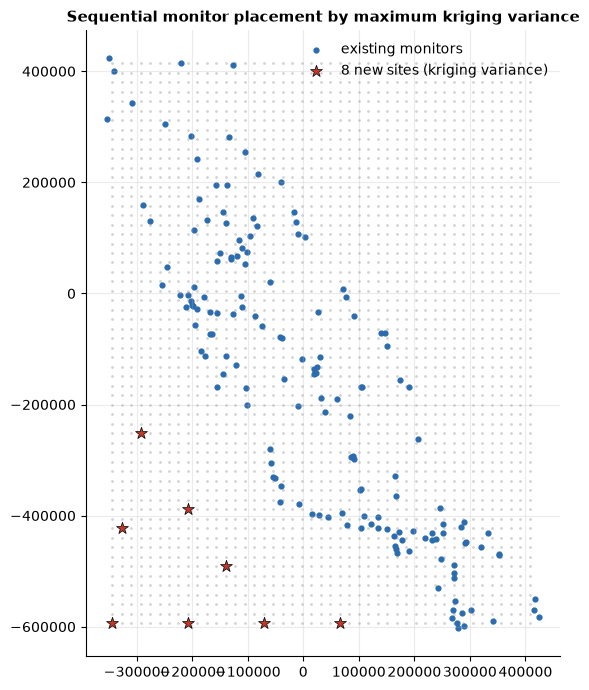

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(reference_grid[:, 0], reference_grid[:, 1], s=1, color="lightgrey")
ax.scatter(monitor_coords[:, 0], monitor_coords[:, 1], s=12, color=COLORS["blue"], label="existing monitors")
new_coords_krig = np.array([loc for loc, _ in new_sites_kriging])
ax.scatter(new_coords_krig[:, 0], new_coords_krig[:, 1], s=80, color=COLORS["red"], marker="*",
          edgecolor="k", linewidth=0.5, label="8 new sites (kriging variance)", zorder=5)
ax.set_title("Sequential monitor placement by maximum kriging variance")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("sequential_kriging_placement.png", dpi=100, bbox_inches="tight")
plt.show()

***
## 6. Sequential Selection by Maximin Distance

A simpler, model-free alternative: place each new site to maximize its **minimum distance** to every existing
and already-chosen site — pure geometric coverage, with no variogram fit required at all.

In [7]:
def sequential_maximin_selection(coords, candidates, n_new):
    cur_coords = coords.copy()
    chosen = []
    for step in range(n_new):
        tree = cKDTree(cur_coords)
        dist, _ = tree.query(candidates)
        best_idx = np.argmax(dist)
        chosen.append((candidates[best_idx].copy(), dist[best_idx]))
        cur_coords = np.vstack([cur_coords, candidates[best_idx]])
    return chosen

new_sites_maximin = sequential_maximin_selection(monitor_coords, reference_grid, n_new=8)
for i, (loc, d) in enumerate(new_sites_maximin):
    print(f"new site {i+1}: ({loc[0]:,.0f}, {loc[1]:,.0f})   distance to nearest existing site = {d/1000:.1f} km")

new_coords_maximin = np.array([loc for loc, _ in new_sites_maximin])
agreement = np.array([np.min(np.linalg.norm(new_coords_maximin - c, axis=1)) < 5000 for c in new_coords_krig])
print(f"\nkriging-variance and maximin picks agree (within 5 km) on {agreement.sum()} of 8 sites")

x_lo, x_hi = reference_grid[:, 0].min(), reference_grid[:, 0].max()
y_lo, y_hi = reference_grid[:, 1].min(), reference_grid[:, 1].max()
tol = 0.02 * max(x_hi - x_lo, y_hi - y_lo)


def on_boundary(pts):
    on_x = (np.abs(pts[:, 0] - x_lo) < tol) | (np.abs(pts[:, 0] - x_hi) < tol)
    on_y = (np.abs(pts[:, 1] - y_lo) < tol) | (np.abs(pts[:, 1] - y_hi) < tol)
    return on_x | on_y


print(f"kriging picks on the candidate grid's outer edge:  {on_boundary(new_coords_krig).sum()} of 8")
print(f"maximin picks on the candidate grid's outer edge:  {on_boundary(new_coords_maximin).sum()} of 8")

new site 1: (407,668, 414,606)   distance to nearest existing site = 496.8 km
new site 2: (-344,272, -593,678)   distance to nearest existing site = 373.0 km
new site 3: (407,668, 106,994)   distance to nearest existing site = 307.6 km
new site 4: (134,235, 397,516)   distance to nearest existing site = 260.5 km
new site 5: (-344,272, -337,335)   distance to nearest existing site = 253.1 km
new site 6: (-105,018, -593,678)   distance to nearest existing site = 227.3 km
new site 7: (407,668, -115,170)   distance to nearest existing site = 222.2 km
new site 8: (202,593, 192,441)   distance to nearest existing site = 216.2 km

kriging-variance and maximin picks agree (within 5 km) on 1 of 8 sites
kriging picks on the candidate grid's outer edge:  5 of 8
maximin picks on the candidate grid's outer edge:  7 of 8


**Both sets of picks sit almost entirely on the candidate grid's own outer edge** — and the two strategies agree
on only 1 of 8 sites, not "closely" as a first look at the summary numbers alone might suggest. This is a real,
important problem with the setup, not a subtle difference between the two criteria: `make_grid`'s candidate
region (Chapter 7.2) is the monitor network's rectangular **bounding box**, which extends well beyond
California's actual coastline and land border — its corners sit in the Pacific Ocean, Nevada, Arizona, Oregon,
and Mexico, none of which are legitimate PM2.5 monitor sites. Both maximum-kriging-variance and maximin-distance
are, correctly, finding the points *in the candidate set* that are farthest from any existing monitor — but
because the candidate set itself was never restricted to real, feasible California territory, "farthest from any
monitor" collapses onto whichever edge of the rectangle happens to be emptiest, and minor differences between the
two criteria (kriging variance flattens out, nearly tied, once well beyond the $\approx$133 km variogram range,
while maximin distance keeps growing strictly with distance) are enough to send them to *different* far corners
of a region that was never meaningfully California in the first place.

***
## 7. Where Would New Monitors Actually Go?

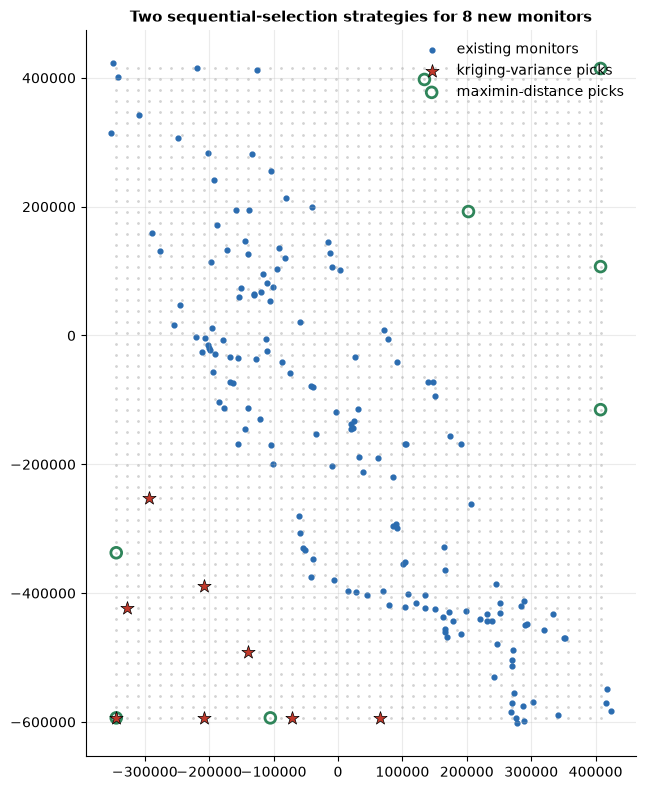

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(reference_grid[:, 0], reference_grid[:, 1], s=1, color="lightgrey")
ax.scatter(monitor_coords[:, 0], monitor_coords[:, 1], s=12, color=COLORS["blue"], label="existing monitors")
ax.scatter(new_coords_krig[:, 0], new_coords_krig[:, 1], s=100, color=COLORS["red"], marker="*",
          edgecolor="k", linewidth=0.5, label="kriging-variance picks", zorder=5)
ax.scatter(new_coords_maximin[:, 0], new_coords_maximin[:, 1], s=60, facecolor="none", edgecolor=COLORS["green"],
          linewidth=2, label="maximin-distance picks", zorder=4)
ax.set_title("Two sequential-selection strategies for 8 new monitors")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("both_strategies_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

The map makes Section 6's finding vivid: nearly every star and circle sits right at the outer boundary of the
plotted region, not scattered through California's genuine coverage gaps in the interior. **The practical lesson
is more important than either algorithm's output**: any sequential-selection loop built on `make_grid`'s
rectangular bounding box will happily recommend a monitor in the ocean if that is where the candidate set says
the largest gap is. Before running either strategy for a real siting decision, the candidate grid must be
**clipped to the actual feasible region** — California's land boundary, minus water bodies, parks, or other
unsuitable land — using a real polygon (as `make_grid` itself supports directly: Chapter 7.2 passed it a point
array for its bounding box, but it accepts a shapely polygon or GeoDataFrame just as easily, restricting
candidates to only the cells whose centre actually falls inside). Only once the candidate set is genuinely
restricted to plausible sites does "where is coverage worst" become a meaningful question to ask at all.

unclipped candidate grid: 2700 cells
clipped to (a buffered hull around) the actual monitor network's footprint: 1239 cells
clipped-grid picks on the ORIGINAL unclipped grid's outer edge: 1 of 8


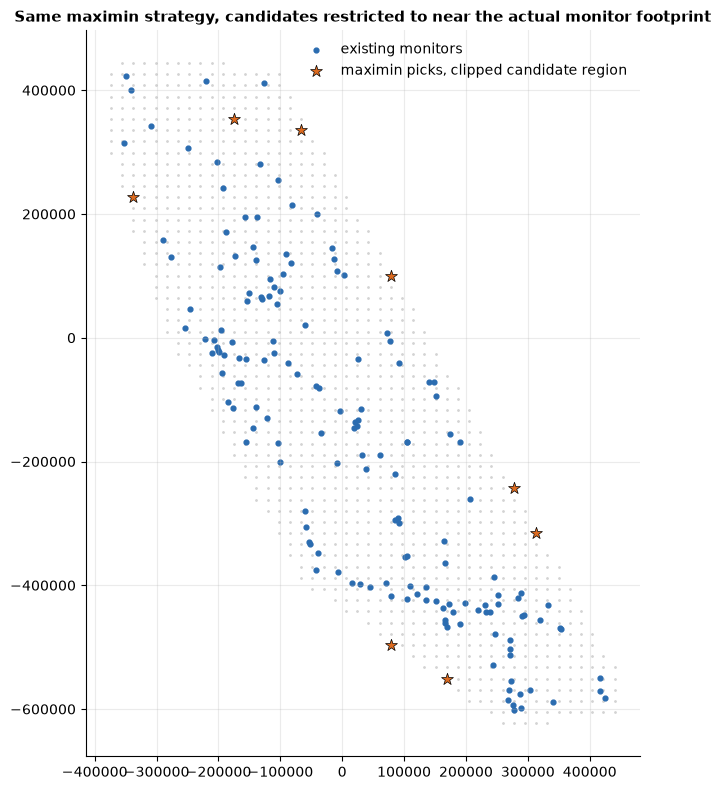

In [9]:
from spatialstats.interpolate import make_grid as make_grid_clipped
import geopandas as gpd
from shapely.geometry import MultiPoint

california_hull = MultiPoint([tuple(c) for c in monitor_coords]).convex_hull.buffer(30_000)
clipped_grid = make_grid_clipped(gpd.GeoDataFrame(geometry=[california_hull], crs="EPSG:3310"), n_cells=60)
print(f"unclipped candidate grid: {len(reference_grid)} cells")
print(f"clipped to (a buffered hull around) the actual monitor network's footprint: {clipped_grid.inside.sum()} cells")

new_sites_clipped = sequential_maximin_selection(monitor_coords, clipped_grid.coords, n_new=8)
new_coords_clipped = np.array([loc for loc, _ in new_sites_clipped])
print(f"clipped-grid picks on the ORIGINAL unclipped grid's outer edge: {on_boundary(new_coords_clipped).sum()} of 8")

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(clipped_grid.coords[:, 0], clipped_grid.coords[:, 1], s=1, color="lightgrey")
ax.scatter(monitor_coords[:, 0], monitor_coords[:, 1], s=12, color=COLORS["blue"], label="existing monitors")
ax.scatter(new_coords_clipped[:, 0], new_coords_clipped[:, 1], s=80, color=COLORS["orange"], marker="*",
          edgecolor="k", linewidth=0.5, label="maximin picks, clipped candidate region", zorder=5)
ax.set_title("Same maximin strategy, candidates restricted to near the actual monitor footprint")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("clipped_candidate_placement.png", dpi=100, bbox_inches="tight")
plt.show()

With the candidate set restricted to a buffered hull around the real monitor footprint — a rough stand-in here
for a true California land-boundary polygon, which this repository does not ship — the new picks move into
genuine interior gaps between existing monitors, not off into a rectangular corner. This is the version of the
exercise worth trusting for an actual siting decision; Section 6's unclipped result is a cautionary example, not
a recommendation.

***
## 8. Summary and Conclusions

This chapter applied this Part's sampling-design tools to a genuinely unsolved, practical problem: evaluating
and improving a real, imperfect monitoring network.

### What we did

1. Measured the real 159-site PM2.5 network's coverage directly: kilometre-scale minimum spacing (near-duplicate
   sites) alongside hundreds-of-kilometres worst-case gaps.
2. **Found a space-filling design of the same size would cut both the mean and maximum distance to the nearest
   monitor by more than half**, while eliminating near-duplicate spacing entirely.
3. Built a sequential kriging-variance placement loop, confirming predicted standard deviation decreases with
   each added site as the model becomes more confident everywhere.
4. Built a simpler maximin-distance alternative requiring no variogram fit at all.
5. **Found the two strategies agree on only 1 of 8 picks, and both cluster almost entirely on the candidate
   grid's outer rectangular edge** — traced directly to `make_grid`'s bounding-box candidate set extending well
   into the Pacific Ocean, Nevada, Arizona, Oregon, and Mexico, none of them legitimate monitor sites.
6. **Fixed it**: restricting the candidate set to a polygon around the real monitor footprint moved the
   recommended sites into genuine interior coverage gaps — the version of this exercise actually worth trusting.

### Practical takeaways

- Audit any existing monitoring network's coverage with `coverage_metrics` before assuming it is well-suited to
  the interpolation task at hand — Part 7's whole cross-validation story (LOO's optimism, Chapter 7.5) traces
  directly back to exactly the clustering this chapter quantifies.
- **Always clip a sequential-selection candidate grid to the actual feasible region before running the loop** —
  a rectangular bounding box will confidently recommend monitors in the ocean or a neighbouring state, and
  neither kriging variance nor maximin distance has any way to know that on its own.
- When redesigning a network from scratch is not an option, sequential kriging-variance selection (on a properly
  clipped candidate set) gives a principled way to prioritize the next few additions using the existing
  network's own fitted model.

### Next steps

**Chapter 8.5 (Exercises)** closes out this Part with five hands-on tasks spanning every design and estimator
introduced across Chapters 8.1–8.4.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Le, N. D. & Zidek, J. V. (2006). *Statistical Analysis of Environmental Space-Time Processes*. Springer. | Network design for environmental monitoring, including variance-based sequential selection |

### Key papers

| Paper | Contribution |
|---|---|
| Royle, J. A. & Nychka, D. (1998). An algorithm for the construction of spatial coverage designs with implementation in SPLUS. *Computers & Geosciences*, 24, 479–488. | The maximin/coverage-design algorithm behind Section 6 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.sampling.coverage_metrics`, `space_filling` | Sections 3–4 |
| `spatialstats.interpolate.OrdinaryKriging` | Section 5's sequential selection loop |
| Chapter 7.4 | The kriging model and variogram range this chapter's Section 7 explanation depends on |